# Procesamiento por Lotes - Cascada de Detección y Clasificación de Moniliasis en Cacao

Este notebook ejecuta la cascada completa sobre todas las imágenes de una carpeta:
1. **YOLO** → detecta mazorcas
2. **Filtro pre-segmentación** → calidad mínima
3. **SAM2** → segmenta cada mazorca
4. **Filtro post-segmentación** → calidad de máscara
5. **ConvNeXt Tiny** → clasifica (sano / enfermo)
6. **Ensamblado** → imagen anotada + CSV con métricas
7. **Evaluación** → matriz de confusión vs ground truth

Los modelos se cargan uno a la vez para liberar memoria entre fases.

In [1]:
"""
# =============================================================================
# Celda 1: Instalación de dependencias dentro del entorno virtual
# =============================================================================
import subprocess
import sys

deps = [
    "ultralytics",
    "torch",
    "torchvision",
    "timm",
    "opencv-python",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "scipy",
    "pillow",
    "tqdm"
]

for dep in deps:
    print(f"Instalando: {dep}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", dep])
print("\nTodas las dependencias instaladas correctamente.")
"""

'\n# =============================================================================\n# Celda 1: Instalación de dependencias dentro del entorno virtual\n# =============================================================================\nimport subprocess\nimport sys\n\ndeps = [\n    "ultralytics",\n    "torch",\n    "torchvision",\n    "timm",\n    "opencv-python",\n    "numpy",\n    "pandas",\n    "matplotlib",\n    "seaborn",\n    "scikit-learn",\n    "scipy",\n    "pillow",\n    "tqdm"\n]\n\nfor dep in deps:\n    print(f"Instalando: {dep}")\n    subprocess.check_call([sys.executable, "-m", "pip", "install", dep])\nprint("\nTodas las dependencias instaladas correctamente.")\n'

In [2]:
# =============================================================================
# Celda 2: CONFIGURACIÓN GENERAL
# =============================================================================
# Ajusta estos valores según necesites antes de ejecutar el pipeline.
# =============================================================================
import os
from pathlib import Path

# ---------------------------------------------------------------------------
# RUTAS
# ---------------------------------------------------------------------------
INPUT_FOLDER = r"D:\Python\Notebook\Dataset\DataLocal_Binario\test\img"
OUTPUT_FOLDER = r"D:\Python\Notebook\Dataset\DataLocal_Binario\test\resultados"
LABELS_FOLDER = r"D:\Python\Notebook\Dataset\DataLocal_Binario\test\lbl"
TEMP_DIR = Path(OUTPUT_FOLDER) / "_temp"

RUTA_YOLO = r"D:\Python\Notebook\Modelos\YOLO_Mixto_BA\weights\best.pt"
RUTA_SAM2 = r"D:\Python\Notebook\sam2_l.pt"
RUTA_CONVNEXT = r"D:\Python\Notebook\Modelos\convnext_tiny_mixto_balanceado.pth"

# ---------------------------------------------------------------------------
# CLASES DEL CLASIFICADOR
# ---------------------------------------------------------------------------
CLASES = ["enfermo", "sano"]  # 0 = enfermo, 1 = sano (debe coincidir con el orden de entrenamiento)

# ---------------------------------------------------------------------------
# FILTRO PRE-SEGMENTACIÓN
# ---------------------------------------------------------------------------
PRE_MIN_W = 50             # Ancho mínimo del crop (px)
PRE_MIN_H = 50             # Alto mínimo del crop (px)
PRE_MIN_AREA = 3000        # Área mínima del crop (px²)
PRE_DARK_V_THR = 30        # Valor V (HSV) para considerar un píxel como oscuro
PRE_MAX_DARK_RATIO = 0.5   # Máxima proporción de píxeles oscuros permitida (0-1)
PRE_CANNY_LOW = 100        # Umbral bajo del detector de bordes Canny
PRE_CANNY_HIGH = 200       # Umbral alto del detector de bordes Canny
PRE_MIN_EDGE_DENSITY = 0.01  # Densidad mínima de bordes para considerar el crop válido

# ---------------------------------------------------------------------------
# SAM2 - SEGMENTACIÓN
# ---------------------------------------------------------------------------
SAM2_CONF = 0.3            # Confianza mínima para que SAM2 genere una máscara
SAM2_MASK_THR = 0.5        # Umbral de binarización de la máscara (píxel > thr = foreground)
SAM2_GAUSS_SIGMA = 3.0     # Sigma del desenfoque Gaussiano para realce de bordes
SAM2_SHARP_ORIG = 1.5      # Peso de la imagen original en el realce
SAM2_SHARP_BLUR = -0.5     # Peso del desenfoque en el realce
SAM2_BILAT_D = 9           # Diámetro del filtro bilateral
SAM2_BILAT_SIGMA_COLOR = 75  # Sigma de color del filtro bilateral
SAM2_BILAT_SIGMA_SPACE = 75  # Sigma espacial del filtro bilateral
SAM2_BLEND_SHARP = 0.7     # Peso de la imagen realzada en la mezcla final
SAM2_BLEND_BILAT = 0.3     # Peso del filtro bilateral en la mezcla final

# ---------------------------------------------------------------------------
# FILTRO POST-SEGMENTACIÓN
# ---------------------------------------------------------------------------
POST_MIN_FG = 0.10         # Proporción mínima de foreground (0-1). Debajo se rechaza
POST_MAX_FG = 0.90         # Proporción máxima de foreground (0-1). Encima se rechaza
POST_MAX_RECT = 0.95       # Extensión máxima (máscara muy rectangular se rechaza)
POST_SQUARE_LOW = 0.95     # Límite inferior de aspect ratio para detectar máscaras cuadradas
POST_SQUARE_HIGH = 1.05    # Límite superior de aspect ratio para detectar máscaras cuadradas
POST_SQUARE_FG = 0.80      # Foreground mínimo para rechazar máscaras casi cuadradas y llenas

# ---------------------------------------------------------------------------
# CONVNEXT - CLASIFICADOR
# ---------------------------------------------------------------------------
MODEL_ARCH = 'convnext_tiny'  # Arquitectura del modelo en timm
NUM_CLASSES = 2               # Número de clases de salida
IMG_SIZE = 224                # Tamaño de entrada del clasificador (px)
NORM_MEAN = [0.485, 0.456, 0.406]  # Media para normalización (ImageNet)
NORM_STD = [0.229, 0.224, 0.225]   # Desviación estándar para normalización (ImageNet)

# ---------------------------------------------------------------------------
# HELPER: REDIMENSIÓN CON PADDING
# ---------------------------------------------------------------------------
PAD_TARGET_SIZE = 224       # Tamaño del canvas cuadrado para resize con padding

# ---------------------------------------------------------------------------
# HELPER: MARGEN PARA RECORTE
# ---------------------------------------------------------------------------
CROP_MARGEN = 0.05          # Margen fraccional (5%) al recortar un bounding box

# ---------------------------------------------------------------------------
# HELPER: MASS ACCURACY
# ---------------------------------------------------------------------------
MASS_ACC_THRESHOLD = 20     # Umbral de gris para considerar un píxel como "válido"

# ---------------------------------------------------------------------------
# EXTENSIONES DE IMAGEN A PROCESAR
# ---------------------------------------------------------------------------
EXTENSIONES = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")

# ---------------------------------------------------------------------------
# VISUALIZACIÓN
# ---------------------------------------------------------------------------
MOSTRAR_MASCARA = True      # True = superpone máscara SAM semitransparente en la salida
GROSOR_BBOX = 4             # Grosor del borde del bounding box (px)
COLOR_SANO = (0, 255, 0)   # Color BGR para mazorcas sanas
COLOR_ENFERMO = (0, 0, 200)  # Color BGR para mazorcas enfermas
COLOR_NO_PROC = (255, 0, 0)  # Color BGR para mazorcas no procesables
OVERLAY_IMG_PESO = 0.7     # Peso de la imagen original en la superposición de máscara
OVERLAY_MASK_PESO = 0.3    # Peso de la máscara en la superposición

# ---------------------------------------------------------------------------
# EVALUACIÓN (matriz de confusión)
# ---------------------------------------------------------------------------
EVAL_IOU_THR = 0.3          # IoU mínimo para parear una detección con su ground truth
IOU_MATCH_THR = 0.5        # IoU mínimo para considerar un pareo válido (evaluación principal)
MODO_EVALUACION = 3        # 1 = solo sin filtros, 2 = solo con filtros, 3 = ambos

# ---------------------------------------------------------------------------
# CREAR DIRECTORIOS
# ---------------------------------------------------------------------------
Path(OUTPUT_FOLDER).mkdir(parents=True, exist_ok=True)
TEMP_DIR.mkdir(parents=True, exist_ok=True)

print(f"Carpeta de entrada: {INPUT_FOLDER}")
print(f"Carpeta de salida: {OUTPUT_FOLDER}")
print(f"Temporales: {TEMP_DIR}")

Carpeta de entrada: D:\Python\Notebook\Dataset\DataLocal_Binario\test\img
Carpeta de salida: D:\Python\Notebook\Dataset\DataLocal_Binario\test\resultados
Temporales: D:\Python\Notebook\Dataset\DataLocal_Binario\test\resultados\_temp


In [3]:
# =============================================================================
# Celda 3: Funciones auxiliares
# =============================================================================
import cv2
import numpy as np
import json
import torch
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


def pre_filter(crop):
    h, w = crop.shape[:2]
    area = h * w

    if w < PRE_MIN_W or h < PRE_MIN_H or area < PRE_MIN_AREA:
        return False, f"Dimensiones mínimas: ancho<{PRE_MIN_W} o alto<{PRE_MIN_H} o área<{PRE_MIN_AREA}"

    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    dark_pixels = np.sum(hsv[:, :, 2] < PRE_DARK_V_THR)
    if dark_pixels / area > PRE_MAX_DARK_RATIO:
        return False, f"Demasiados píxeles oscuros (>={PRE_MAX_DARK_RATIO:.0%} con V<{PRE_DARK_V_THR})"

    edges = cv2.Canny(crop, PRE_CANNY_LOW, PRE_CANNY_HIGH)
    edge_density = np.sum(edges > 0) / area
    if edge_density < PRE_MIN_EDGE_DENSITY:
        return False, f"Densidad de bordes muy baja (<{PRE_MIN_EDGE_DENSITY})"

    return True, ""


def post_filter(mask, crop_shape):
    h, w = crop_shape[:2]
    area_total = h * w
    area_mask = np.sum(mask > 0)

    if area_mask == 0:
        return False, "Máscara vacía (todos los píxeles a cero)"

    prop_fg = area_mask / area_total

    if prop_fg < POST_MIN_FG:
        return False, f"Máscara muy pequeña (foreground {prop_fg:.2%} < {POST_MIN_FG:.0%})"
    if prop_fg > POST_MAX_FG:
        return False, f"Máscara muy grande (foreground {prop_fg:.2%} > {POST_MAX_FG:.0%})"

    coords = np.column_stack(np.where(mask > 0))
    if len(coords) > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        bbox_w = x_max - x_min + 1
        bbox_h = y_max - y_min + 1
        extension = area_mask / (bbox_w * bbox_h) if (bbox_w * bbox_h) > 0 else 1
        if extension > POST_MAX_RECT:
            return False, f"Forma muy rectangular (extensión {extension:.2f} > {POST_MAX_RECT})"

        ratio = bbox_w / bbox_h if bbox_h > 0 else 999
        if POST_SQUARE_LOW < ratio < POST_SQUARE_HIGH and prop_fg > POST_SQUARE_FG:
            return False, f"Máscara casi cuadrada y llena (ratio={ratio:.2f}, fg={prop_fg:.2%})"

    return True, ""


def resize_con_padding(img, target_size=None):
    if target_size is None:
        target_size = PAD_TARGET_SIZE
    h, w = img.shape[:2]
    if h == 0 or w == 0:
        return None
    scale = min(target_size / w, target_size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    x_off = (target_size - new_w) // 2
    y_off = (target_size - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas


def mass_accuracy(masked_img, threshold=None):
    if threshold is None:
        threshold = MASS_ACC_THRESHOLD
    gray = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
    total = gray.size
    if total == 0:
        return 0.0
    return float(np.sum(gray > threshold)) / total


def crop_con_margen(img, x1, y1, x2, y2, margen=None):
    if margen is None:
        margen = CROP_MARGEN
    h_img, w_img = img.shape[:2]
    ancho = x2 - x1
    alto = y2 - y1
    dx = int(ancho * margen)
    dy = int(alto * margen)
    x1_c = max(0, x1 - dx)
    y1_c = max(0, y1 - dy)
    x2_c = min(w_img, x2 + dx)
    y2_c = min(h_img, y2 + dy)
    return img[y1_c:y2_c, x1_c:x2_c].copy()


def preprocess_for_segmentation(img_rgb):
    blurred = cv2.GaussianBlur(img_rgb, (0, 0), SAM2_GAUSS_SIGMA)
    img_sharp = cv2.addWeighted(img_rgb, SAM2_SHARP_ORIG, blurred, SAM2_SHARP_BLUR, 0)
    img_bilateral = cv2.bilateralFilter(img_sharp, SAM2_BILAT_D, SAM2_BILAT_SIGMA_COLOR, SAM2_BILAT_SIGMA_SPACE)
    img_enhanced = cv2.addWeighted(img_sharp, SAM2_BLEND_SHARP, img_bilateral, SAM2_BLEND_BILAT, 0)
    return np.clip(img_enhanced, 0, 255).astype(np.uint8)


def get_best_mask(masks_np, img_shape):
    h, w = img_shape[:2]
    img_center = np.array([h / 2, w / 2])
    mask_list = [masks_np[i] for i in range(masks_np.shape[0])]

    def distance_to_center(mask):
        coords = np.column_stack(np.where(mask == 255))
        if len(coords) == 0:
            return float('inf')
        centroid = coords.mean(axis=0)
        return np.linalg.norm(centroid - img_center)

    sorted_masks = sorted(mask_list, key=distance_to_center)
    return sorted_masks[0] if sorted_masks else None

Dispositivo: cuda


---
## FASE 1: YOLO - Detección de mazorcas
---

In [4]:
# =============================================================================
# Celda 4: Cargar YOLO y procesar todas las imágenes
# =============================================================================
from ultralytics import YOLO

# Cargar YOLO
print("Cargando YOLO...")
modelo_yolo = YOLO(RUTA_YOLO)
modelo_yolo.to(device)
print("YOLO cargado.")

# Diccionario maestro con todos los resultados
metadatos = {}

# Obtener lista de imágenes
archivos_img = []
for ext in EXTENSIONES:
    archivos_img.extend(Path(INPUT_FOLDER).glob(ext))
archivos_img = sorted(archivos_img)
print(f"Imágenes encontradas: {len(archivos_img)}")

total_dets = 0
for ruta_img in tqdm(archivos_img, desc="YOLO - Detectando"):
    nombre = ruta_img.name
    img = cv2.imread(str(ruta_img))
    if img is None:
        print(f"  Error al leer {nombre}")
        continue

    # Inferencia YOLO
    resultados = modelo_yolo(img, verbose=False)

    detecciones = []
    if len(resultados) > 0 and resultados[0].boxes is not None:
        boxes = resultados[0].boxes.xyxy.cpu().numpy()
        confs = resultados[0].boxes.conf.cpu().numpy()

        for idx, (box, conf) in enumerate(zip(boxes, confs)):
            x1, y1, x2, y2 = map(int, box)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)

            # Recortar con margen del 5%
            crop = crop_con_margen(img, x1, y1, x2, y2)

            # Pre-filter
            pasa_pre, razon_pre = pre_filter(crop)

            det_id = f"det{idx:03d}"
            info_det = {
                "det_id": det_id,
                "bbox": [int(x1), int(y1), int(x2), int(y2)],
                "confianza_yolo": float(conf),
                "pre_filter_pasa": bool(pasa_pre),
                "pre_filter_razon": razon_pre,
                "crop_path": None,
                "mask_path": None,
                "masked_crop_path": None,
                "post_filter_pasa": None,
                "post_filter_razon": "",
                "prediccion": None,
                "confianza_clf": None,
                "mass_accuracy": None
            }

            if pasa_pre:
                # Guardar crop temporal
                crop_nombre = f"{ruta_img.stem}_{det_id}_crop.jpg"
                crop_path = TEMP_DIR / crop_nombre
                cv2.imwrite(str(crop_path), crop)
                info_det["crop_path"] = str(crop_path)

            detecciones.append(info_det)

    metadatos[nombre] = {
        "ruta_original": str(ruta_img),
        "shape": list(img.shape),
        "detecciones": detecciones
    }
    total_dets += len(detecciones)

print(f"\nTotal detecciones encontradas: {total_dets}")

# Liberar YOLO
del modelo_yolo
torch.cuda.empty_cache()
print("YOLO liberado. Memoria liberada.")

Cargando YOLO...
YOLO cargado.
Imágenes encontradas: 110


YOLO - Detectando:   0%|          | 0/110 [00:00<?, ?it/s]


Total detecciones encontradas: 224
YOLO liberado. Memoria liberada.


---
## FASE 2: SAM2 - Segmentación de cada recorte
---

In [5]:
# =============================================================================
# Celda 5: Cargar SAM2
# =============================================================================
from ultralytics import SAM

print("Cargando SAM2...")
model_sam = SAM(RUTA_SAM2)
print("SAM2 cargado.")

Cargando SAM2...
SAM2 cargado.


In [6]:
# =============================================================================
# Celda 6: Segmentar todos los recortes con SAM2
# =============================================================================
from PIL import Image

print("Segmentando recortes con SAM2...")

total_crops = sum(
    len(info["detecciones"]) for info in metadatos.values()
)
procesados = 0

for nombre_img, info_img in tqdm(metadatos.items(), desc="SAM2 - Segmentando"):
    for det in info_img["detecciones"]:
        if not det["pre_filter_pasa"]:
            continue

        crop_path = det["crop_path"]
        crop = cv2.imread(crop_path)
        if crop is None:
            det["post_filter_pasa"] = False
            det["post_filter_razon"] = "Error al leer crop"
            continue

        try:
            # Preprocesar como en segmentadorManual.py (realzar bordes antes de SAM2)
            crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            enhanced = preprocess_for_segmentation(crop_rgb)
            results_sam = model_sam.predict(source=enhanced, conf=SAM2_CONF, device=device, verbose=False)

            if len(results_sam) == 0 or results_sam[0].masks is None or len(results_sam[0].masks.data) == 0:
                det["post_filter_pasa"] = False
                det["post_filter_razon"] = "SAM2 sin mÃ¡scaras"
                continue

            # Umbral > 0.5 (igual que en segmentadorManual, no > 0.0)
            masks_np = results_sam[0].masks.data.cpu().numpy().astype(np.uint8)
            masks_np = (masks_np > SAM2_MASK_THR).astype(np.uint8) * 255

            # Seleccionar la mÃ¡scara mÃ¡s cercana al centro (como en segmentadorManual)
            best_mask = get_best_mask(masks_np, crop.shape)
            if best_mask is None:
                det["post_filter_pasa"] = False
                det["post_filter_razon"] = "Ninguna mÃ¡scara vÃ¡lida"
                continue
            mask = best_mask

            # Post-filter
            pasa_post, razon_post = post_filter(mask, crop.shape)
            det["post_filter_pasa"] = bool(pasa_post)
            det["post_filter_razon"] = razon_post

            if pasa_post:
                # Aplicar máscara (fondo negro)
                masked = cv2.bitwise_and(crop, crop, mask=mask)

                # Guardar máscara y masked crop
                mask_nombre = f"{Path(crop_path).stem}_mask.png"
                masked_nombre = f"{Path(crop_path).stem}_masked.jpg"
                mask_path = TEMP_DIR / mask_nombre
                masked_path = TEMP_DIR / masked_nombre
                cv2.imwrite(str(mask_path), mask)
                cv2.imwrite(str(masked_path), masked)

                det["mask_path"] = str(mask_path)
                det["masked_crop_path"] = str(masked_path)
                det["mass_accuracy"] = mass_accuracy(masked)
            else:
                # No procesable - registrar motivo
                pass

        except Exception as e:
            det["post_filter_pasa"] = False
            det["post_filter_razon"] = f"Error SAM2: {str(e)}"

        procesados += 1

print(f"\nRecortes procesados con SAM2: {procesados}")

# Liberar SAM2
torch.cuda.empty_cache()
print("SAM2 liberado. Memoria liberada.")


Segmentando recortes con SAM2...


SAM2 - Segmentando:   0%|          | 0/110 [00:00<?, ?it/s]


Recortes procesados con SAM2: 166
SAM2 liberado. Memoria liberada.


---
## FASE 3: ConvNeXt Tiny - Clasificación
---

In [7]:
# =============================================================================
# Celda 7: Cargar ConvNeXt y clasificar
# =============================================================================
import timm
from torchvision import transforms

print("Cargando ConvNeXt...")
modelo_convnext = timm.create_model(MODEL_ARCH, pretrained=False, num_classes=NUM_CLASSES)
checkpoint = torch.load(RUTA_CONVNEXT, map_location=device, weights_only=True)
if "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint
modelo_convnext.load_state_dict(state_dict)
modelo_convnext.to(device)
modelo_convnext.eval()
print("ConvNeXt cargado.")

# Transformación para ConvNeXt:
# Primero se aplica resize_con_padding (manteniendo aspect ratio con bordes negros)
# sobre la imagen numpy, luego ToTensor + Normalize.
transform_clf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN,
                         std=NORM_STD)
])

Cargando ConvNeXt...
ConvNeXt cargado.


In [8]:
# =============================================================================
# Celda 8: Clasificar todos los recortes segmentados
# =============================================================================
print("Clasificando recortes segmentados...")

total_clasificados = 0
for nombre_img, info_img in tqdm(metadatos.items(), desc="ConvNeXt - Clasificando"):
    for det in info_img["detecciones"]:
        if not (det["pre_filter_pasa"] and det.get("post_filter_pasa")):
            continue

        masked_path = det["masked_crop_path"]
        if masked_path is None or not os.path.exists(masked_path):
            continue

        masked = cv2.imread(masked_path)
        if masked is None:
            continue

        masked_rgb = cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)
        masked_padded = resize_con_padding(masked_rgb, IMG_SIZE)
        tensor = transform_clf(masked_padded).unsqueeze(0).to(device)

        with torch.no_grad():
            salida = modelo_convnext(tensor)
            probs = torch.softmax(salida, dim=1)[0]
            pred_cls = int(torch.argmax(probs).item())
            confianza = float(probs[pred_cls].item())

        det["prediccion"] = CLASES[pred_cls]
        det["confianza_clf"] = round(confianza, 4)
        total_clasificados += 1

print(f"\nRecortes clasificados: {total_clasificados}")

# Liberar ConvNeXt
del modelo_convnext
torch.cuda.empty_cache()
print("ConvNeXt liberado. Memoria liberada.")

# Guardar metadatos completos a JSON
with open(TEMP_DIR / "metadatos_completos.json", "w", encoding="utf-8") as f:
    json.dump(metadatos, f, indent=2, ensure_ascii=False)
print("Metadatos guardados.")

Clasificando recortes segmentados...


ConvNeXt - Clasificando:   0%|          | 0/110 [00:00<?, ?it/s]


Recortes clasificados: 140
ConvNeXt liberado. Memoria liberada.
Metadatos guardados.


---
## FASE 4: Ensamblado - Imágenes anotadas y CSV
---

In [9]:
# =============================================================================
# Celda 9: Generar imágenes anotadas y CSV de métricas
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt

print("Generando imágenes anotadas y CSV...")

# Colores (definidos en Celda 2)

registros_csv = []

for nombre_img, info_img in tqdm(metadatos.items(), desc="Ensamblando"):
    ruta_orig = info_img["ruta_original"]
    img = cv2.imread(ruta_orig)
    if img is None:
        continue

    # Estadísticas para CSV
    n_procesables = 0
    n_no_procesables = 0
    n_sanos = 0
    n_enfermos = 0
    motivos_no_procesable = []

    for det in info_img["detecciones"]:
        x1, y1, x2, y2 = det["bbox"]

        es_procesable = (
            det["pre_filter_pasa"]
            and det.get("post_filter_pasa") is True
            and det.get("prediccion") is not None
        )

        if es_procesable:
            n_procesables += 1
            etiqueta = f"{det['prediccion']} ({det['confianza_clf']:.2f})"
            if det['prediccion'] == 'sano':
                n_sanos += 1
                color = COLOR_SANO
            else:
                n_enfermos += 1
                color = COLOR_ENFERMO
        else:
            n_no_procesables += 1
            # Determinar motivo
            if not det["pre_filter_pasa"]:
                motivo = det["pre_filter_razon"]
            elif det.get("post_filter_pasa") is False:
                motivo = det.get("post_filter_razon", "Fallo post-filter")
            else:
                motivo = "Error en clasificación"
            motivos_no_procesable.append(motivo)
            etiqueta = "No Proc"
            color = COLOR_NO_PROC

        # Dibujar bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), color, GROSOR_BBOX)
        # Dibujar etiqueta
        (tw, th), _ = cv2.getTextSize(etiqueta, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1 - th - 4), (x1 + tw, y1), color, -1)
        cv2.putText(img, etiqueta, (x1, y1 - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        # MÃ¡scara SAM semi-transparente
        if MOSTRAR_MASCARA and es_procesable and det.get("mask_path") and os.path.exists(det["mask_path"]):
            m_mask = cv2.imread(det["mask_path"], cv2.IMREAD_GRAYSCALE)
            if m_mask is not None:
                bbox_w = x2 - x1
                bbox_h = y2 - y1
                if m_mask.shape[0] != bbox_h or m_mask.shape[1] != bbox_w:
                    m_mask = cv2.resize(m_mask, (bbox_w, bbox_h), interpolation=cv2.INTER_NEAREST)
                overlay_color = (0, 255, 255)
                overlay = np.zeros_like(img)
                overlay[y1:y1 + bbox_h, x1:x1 + bbox_w][m_mask > 0] = overlay_color
                img = cv2.addWeighted(img, OVERLAY_IMG_PESO, overlay, OVERLAY_MASK_PESO, 0).astype(np.uint8)

    # Guardar imagen anotada
    img_out_path = Path(OUTPUT_FOLDER) / nombre_img
    cv2.imwrite(str(img_out_path), img)

    # Registrar para CSV
    registros_csv.append({
        "nombre_imagen": nombre_img,
        "n_mazorcas_detectadas": len(info_img["detecciones"]),
        "n_procesables": n_procesables,
        "n_no_procesables": n_no_procesables,
        "n_sanos": n_sanos,
        "n_enfermos": n_enfermos,
        "motivos_no_procesable": "; ".join(motivos_no_procesable)
        if motivos_no_procesable else ""
    })

# Crear DataFrame y guardar CSV
df_csv = pd.DataFrame(registros_csv)
csv_path = Path(OUTPUT_FOLDER) / "reporte_lote.csv"
df_csv.to_csv(csv_path, index=False, encoding="utf-8")

print(f"\nCSV guardado en: {csv_path}")
print(f"\nResumen del lote:")
print(df_csv.describe().to_string())
print(f"\nTotales:")
print(f"  Imágenes procesadas: {len(df_csv)}")
print(f"  Mazorcas detectadas: {df_csv['n_mazorcas_detectadas'].sum()}")
print(f"  Procesables: {df_csv['n_procesables'].sum()}")
print(f"  No procesables: {df_csv['n_no_procesables'].sum()}")
print(f"  Sanas: {df_csv['n_sanos'].sum()}")
print(f"  Enfermas: {df_csv['n_enfermos'].sum()}")

Generando imágenes anotadas y CSV...


Ensamblando:   0%|          | 0/110 [00:00<?, ?it/s]


CSV guardado en: D:\Python\Notebook\Dataset\DataLocal_Binario\test\resultados\reporte_lote.csv

Resumen del lote:
       n_mazorcas_detectadas  n_procesables  n_no_procesables     n_sanos  n_enfermos
count             110.000000     110.000000        110.000000  110.000000  110.000000
mean                2.036364       1.272727          0.763636    0.609091    0.663636
std                 2.403847       1.048451          2.188071    0.779266    0.732938
min                 0.000000       0.000000          0.000000    0.000000    0.000000
25%                 1.000000       1.000000          0.000000    0.000000    0.000000
50%                 1.000000       1.000000          0.000000    0.000000    1.000000
75%                 3.000000       2.000000          1.000000    1.000000    1.000000
max                18.000000       6.000000         18.000000    3.000000    3.000000

Totales:
  Imágenes procesadas: 110
  Mazorcas detectadas: 224
  Procesables: 140
  No procesables: 84
  Sanas

---
## EVALUACIÓN vs GROUND TRUTH
---

Modo de evaluación: 3 - Ambos escenarios

Pareando detecciones con ground truth...


Evaluando:   0%|          | 0/110 [00:00<?, ?it/s]


Total cajas reales (GT): 202
Total detecciones YOLO: 224
  Pareadas con GT: 172
  Falsos positivos (sin pareo): 52
  Falsos negativos (GT sin detección): 30
  Cobertura YOLO: 172/202 (85.1%)

ESCENARIO 1: SIN FILTROS (con categoría No Procesable)

Muestras evaluadas: 172
              precision    recall  f1-score   support

        sano     0.8197    0.5556    0.6623        90
     enfermo     0.9552    0.7805    0.8591        82

   micro avg     0.8906    0.6628    0.7600       172
   macro avg     0.8874    0.6680    0.7607       172
weighted avg     0.8843    0.6628    0.7561       172


Desglose de 'No Procesable' (total: 44):
  Rechazos pre-filtro: 56
  Rechazos post-filtro (SAM2): 28

Top causas de rechazo:
  Dimensiones mínimas: ancho<50 o alto<50 o área<3000: 48
  Demasiados píxeles oscuros (>=50% con V<30): 5
  Máscara vacía (todos los píxeles a cero): 4
  Densidad de bordes muy baja (<0.01): 3
  SAM2 sin mÃ¡scaras: 2
  Máscara muy pequeña (foreground 1.71% < 10%): 1
  Másc

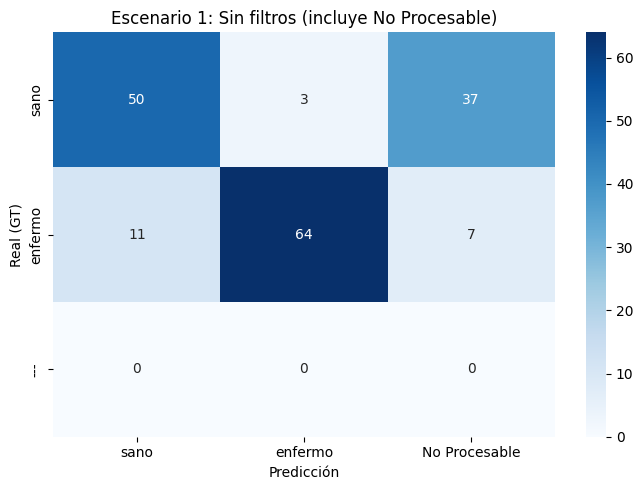


Aciertos directos: 114/172 (66.3%)
Tasa de No Procesable: 44/172 (25.6%)
ESCENARIO 2: CON FILTROS (solo procesables)

Muestras evaluadas: 128
              precision    recall  f1-score   support

        sano     0.9552    0.8533    0.9014        75
     enfermo     0.8197    0.9434    0.8772        53

    accuracy                         0.8906       128
   macro avg     0.8874    0.8984    0.8893       128
weighted avg     0.8991    0.8906    0.8914       128



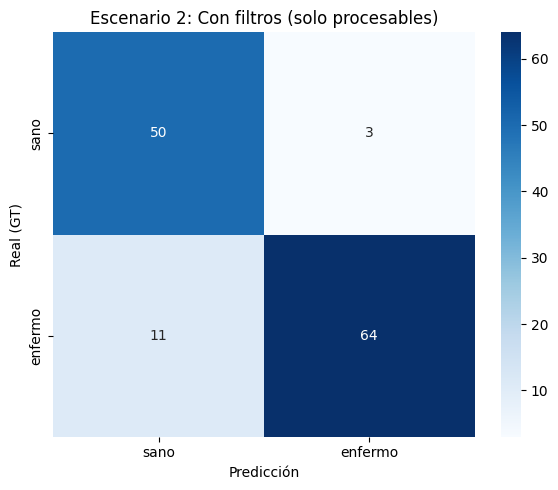


Aciertos: 114/128 (89.1%)
MÉTRICAS DE COBERTURA DEL PIPELINE

Mazorcas reales (GT total): 202
  Detectadas por YOLO y pareadas: 172 (85.1%)
  Pasaron todos los filtros y clasificadas: 128 (63.4%)
  Falsos negativos (GT no detectadas): 30 (14.9%)
  Falsos positivos (detecciones sin GT): 52
  Descartadas por filtros: 44 (25.6% de las pareadas)

CSV de evaluación guardado en: D:\Python\Notebook\Dataset\DataLocal_Binario\test\resultados\evaluacion_detallada.csv

Evaluación completada.


In [10]:
# =============================================================================
# Celda 10: EVALUACIÓN DOBLE DE LA CASCADA COMPLETA
# =============================================================================
# Evalúa el pipeline en dos escenarios:
#   1 - SIN FILTROS: considera TODAS las detecciones YOLO, las filtradas se etiquetan "No Procesable"
#   2 - CON FILTROS: solo detecciones que pasaron todos los filtros y llegaron al clasificador
#
# Ground truth: archivos .txt YOLO (clase 0 = sano, clase 1 = enfermo)
# =============================================================================

from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
from tqdm.notebook import tqdm
import seaborn as sns
import pandas as pd

# -----------------------------------------------------------------------
# MAPEO DE CLASES
# -----------------------------------------------------------------------
# GT en YOLO:  0 = sano, 1 = enfermo
# CLASES (pred): ["enfermo", "sano"] -> índice 0 = enfermo, 1 = sano
GT_CLASES = ["sano", "enfermo"]  # índice 0 = sano, índice 1 = enfermo
NOMBRES_PRED = ["sano", "enfermo", "No Procesable"]  # 0, 1, 2

# -----------------------------------------------------------------------
# CONFIGURACIÓN DEL ANÁLISIS (definido en Celda 2: MODO_EVALUACION)
# -----------------------------------------------------------------------
modo = MODO_EVALUACION
modos_str = {1: "Solo SIN FILTROS", 2: "Solo CON FILTROS", 3: "Ambos escenarios"}
print(f"Modo de evaluación: {modo} - {modos_str.get(modo, 'Desconocido')}")

# -----------------------------------------------------------------------
# CARGA DE GROUND TRUTH Y PAREADO IoU
# -----------------------------------------------------------------------
print("\nPareando detecciones con ground truth...")

resultados_por_imagen = []

# Acumuladores globales
total_gt = 0            # total de cajas reales en todas las imágenes
total_dets = 0          # total de detecciones YOLO
total_fp = 0            # detecciones YOLO sin pareo (FP)
total_fn = 0            # cajas reales sin pareo (FN)

# Para escenario 1 (sin filtros): y_true_1 / y_pred_1
y_true_1 = []  # etiqueta GT: "sano" o "enfermo"
y_pred_1 = []  # predicción: "sano", "enfermo" o "No Procesable"

# Para escenario 2 (con filtros): solo detecciones pareadas que pasaron todo
y_true_2 = []  # etiqueta GT
y_pred_2 = []  # predicción "sano" o "enfermo"

for nombre_img, info_img in tqdm(metadatos.items(), desc="Evaluando"):
    ruta_orig = info_img.get("ruta_original", "")
    img_h, img_w = info_img["shape"][:2]

    # --- Cargar ground truth ---
    lbl_path = Path(LABELS_FOLDER) / f"{Path(nombre_img).stem}.txt"
    gt_boxes = []
    gt_labels = []  # strings: "sano" o "enfermo"
    if lbl_path.exists():
        with open(lbl_path, "r") as f:
            for linea in f:
                linea = linea.strip()
                if not linea:
                    continue
                partes = linea.split()
                cls = int(partes[0])
                xc, yc, w, h = map(float, partes[1:5])
                x1 = int((xc - w / 2) * img_w)
                y1 = int((yc - h / 2) * img_h)
                x2 = int((xc + w / 2) * img_w)
                y2 = int((yc + h / 2) * img_h)
                gt_boxes.append([x1, y1, x2, y2])
                gt_labels.append(GT_CLASES[cls])

    n_gt = len(gt_boxes)
    total_gt += n_gt

    # --- Detecciones YOLO de esta imagen ---
    dets = info_img["detecciones"]
    n_dets = len(dets)
    total_dets += n_dets

    # --- Para cada GT, encontrar la mejor detección ---
    # gt_match[ig] = idx de detección o -1 si no hay match
    gt_match = [-1] * n_gt
    gt_match_iou = [0.0] * n_gt

    # Para cada detección, encontrar el mejor GT
    # det_match[idet] = índice de GT al que se empareja, o -1 si FP
    det_match = [-1] * n_dets
    det_match_iou = [0.0] * n_dets

    def iou(box1, box2):
        xi1 = max(box1[0], box2[0])
        yi1 = max(box1[1], box2[1])
        xi2 = min(box1[2], box2[2])
        yi2 = min(box1[3], box2[3])
        inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
        a1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        a2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
        union = a1 + a2 - inter
        return inter / union if union > 0 else 0

    # Primera pasada: asignar cada detección al GT con mayor IoU
    for idet, det in enumerate(dets):
        best_iou = 0
        best_gt = -1
        for ig in range(n_gt):
            val = iou(det["bbox"], gt_boxes[ig])
            if val > best_iou:
                best_iou = val
                best_gt = ig
        det_match[idet] = best_gt
        det_match_iou[idet] = best_iou

    # Segunda pasada: resolver conflictos (varios dets al mismo GT)
    # Asignar cada GT a la detección con mayor IoU
    for ig in range(n_gt):
        best_iou = 0
        best_det = -1
        for idet in range(n_dets):
            if det_match[idet] == ig and det_match_iou[idet] > best_iou:
                best_iou = det_match_iou[idet]
                best_det = idet
        if best_det >= 0 and best_iou >= IOU_MATCH_THR:
            gt_match[ig] = best_det
            gt_match_iou[ig] = best_iou
        # Las demás detecciones que apuntaban a este GT se quedan sin pareo

    # Recalcular det_match basado en los GT asignados
    det_match = [-1] * n_dets
    det_match_iou = [0.0] * n_dets
    for ig in range(n_gt):
        if gt_match[ig] >= 0:
            det_match[gt_match[ig]] = ig
            det_match_iou[gt_match[ig]] = gt_match_iou[ig]

    # --- Contabilizar ---
    n_fn = sum(1 for m in gt_match if m < 0)  # GT sin detección
    total_fn += n_fn
    n_fp_imagen = 0

    for idet, det in enumerate(dets):
        ig = det_match[idet]
        if ig < 0:
            # Detección sin pareo -> falso positivo
            n_fp_imagen += 1
            total_fp += 1
            continue

        gt_label = gt_labels[ig]
        pasa_pre = det.get("pre_filter_pasa", False)
        pasa_post = det.get("post_filter_pasa", False)
        pasa_filtros = pasa_pre and pasa_post
        pred = det.get("prediccion")  # "sano" o "enfermo" o None

        if not pasa_filtros or pred is None:
            # No pasó filtros -> "No Procesable"
            y_true_1.append(gt_label)
            y_pred_1.append("No Procesable")
        else:
            y_true_1.append(gt_label)
            y_pred_1.append(pred)
            y_true_2.append(gt_label)
            y_pred_2.append(pred)

    # --- Registrar por imagen para CSV ---
    n_procesables = sum(1 for det in dets
                        if det.get("pre_filter_pasa") and det.get("post_filter_pasa")
                        and det.get("prediccion") is not None)
    n_no_proc_imagen = sum(1 for det in dets if not det.get("pre_filter_pasa")
                          or not det.get("post_filter_pasa")
                          or det.get("prediccion") is None)
    n_aciertos = sum(1 for i in range(len(y_true_1))
                     if len(y_true_1) > 0 and y_true_1[i] == y_pred_1[i])

    resultados_por_imagen.append({
        "imagen": nombre_img,
        "n_gt": n_gt,
        "n_detecciones": n_dets,
        "n_fn": n_fn,
        "n_procesables": n_procesables,
        "n_no_procesables": n_no_proc_imagen,
        "n_fp": n_fp_imagen
    })

total_pareadas = len(y_true_1)
print(f"\nTotal cajas reales (GT): {total_gt}")
print(f"Total detecciones YOLO: {total_dets}")
print(f"  Pareadas con GT: {total_pareadas}")
print(f"  Falsos positivos (sin pareo): {total_fp}")
print(f"  Falsos negativos (GT sin detección): {total_fn}")
print(f"  Cobertura YOLO: {total_pareadas}/{total_gt} ({total_pareadas/max(total_gt,1)*100:.1f}%)\n")

# -----------------------------------------------------------------------
# ESCENARIO 1: SIN FILTROS
# -----------------------------------------------------------------------
if modo in (1, 3):
    print("=" * 60)
    print("ESCENARIO 1: SIN FILTROS (con categoría No Procesable)")
    print("=" * 60)

    clases_esc1 = ["sano", "enfermo", "No Procesable"]
    n_pred = len(clases_esc1)
    n_true = 2  # solo sano y enfermo en GT

    cm1 = confusion_matrix(y_true_1, y_pred_1, labels=clases_esc1)
    # cm1 es 3×3 pero la fila "No Procesable" siempre será 0 porque no existe en GT

    print(f"\nMuestras evaluadas: {len(y_true_1)}")

    # Reporte solo para clases reales
    report1 = classification_report(
        y_true_1, y_pred_1,
        labels=["sano", "enfermo"],
        target_names=["sano", "enfermo"],
        digits=4, zero_division=0
    )
    print(report1)

    # Desglose de "No Procesable" por causa
    causas = Counter()
    for nombre_img, info_img in metadatos.items():
        for det in info_img["detecciones"]:
            if not det.get("pre_filter_pasa"):
                causas[det.get("pre_filter_razon", "Pre-filter desconocido")] += 1
            elif not det.get("post_filter_pasa"):
                causas[det.get("post_filter_razon", "Post-filter desconocido")] += 1

    n_pre = sum(v for k, v in causas.items() if k.startswith("Dimensiones") or k.startswith("Demasiados") or k.startswith("Densidad"))
    n_post = sum(v for k, v in causas.items() if not (k.startswith("Dimensiones") or k.startswith("Demasiados") or k.startswith("Densidad")))
    n_no_proc_total = sum(1 for p in y_pred_1 if p == "No Procesable")
    print(f"\nDesglose de 'No Procesable' (total: {n_no_proc_total}):")
    print(f"  Rechazos pre-filtro: {n_pre}")
    print(f"  Rechazos post-filtro (SAM2): {n_post}")
    print(f"\nTop causas de rechazo:")
    for motivo, count in causas.most_common(8):
        print(f"  {motivo}: {count}")

    # Matriz de confusión 3×3 (columnas = predicción, filas = real)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues",
                xticklabels=clases_esc1,
                yticklabels=["sano", "enfermo", "---"])
    plt.ylabel("Real (GT)")
    plt.xlabel("Predicción")
    plt.title("Escenario 1: Sin filtros (incluye No Procesable)")
    plt.tight_layout()
    plt.show()

    # Métricas adicionales
    if len(y_true_1) > 0:
        aciertos_esc1 = sum(1 for t, p in zip(y_true_1, y_pred_1) if t == p)
        print(f"\nAciertos directos: {aciertos_esc1}/{len(y_true_1)} ({aciertos_esc1/len(y_true_1)*100:.1f}%)")
        print(f"Tasa de No Procesable: {n_no_proc_total}/{len(y_true_1)} ({n_no_proc_total/len(y_true_1)*100:.1f}%)")

# -----------------------------------------------------------------------
# ESCENARIO 2: CON FILTROS
# -----------------------------------------------------------------------
if modo in (2, 3):
    print("=" * 60)
    print("ESCENARIO 2: CON FILTROS (solo procesables)")
    print("=" * 60)

    if len(y_true_2) == 0:
        print("No hay detecciones procesables pareadas con GT para evaluar.")
    else:
        clases_esc2 = ["sano", "enfermo"]
        cm2 = confusion_matrix(y_true_2, y_pred_2, labels=clases_esc2)

        print(f"\nMuestras evaluadas: {len(y_true_2)}")
        report2 = classification_report(
            y_true_2, y_pred_2,
            target_names=["sano", "enfermo"],
            digits=4, zero_division=0
        )
        print(report2)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues",
                    xticklabels=clases_esc2,
                    yticklabels=clases_esc2)
        plt.ylabel("Real (GT)")
        plt.xlabel("Predicción")
        plt.title("Escenario 2: Con filtros (solo procesables)")
        plt.tight_layout()
        plt.show()

        aciertos_esc2 = sum(1 for t, p in zip(y_true_2, y_pred_2) if t == p)
        print(f"\nAciertos: {aciertos_esc2}/{len(y_true_2)} ({aciertos_esc2/len(y_true_2)*100:.1f}%)")

# -----------------------------------------------------------------------
# MÉTRICAS GLOBALES DE COBERTURA
# -----------------------------------------------------------------------
if modo in (1, 2, 3):
    print("=" * 60)
    print("MÉTRICAS DE COBERTURA DEL PIPELINE")
    print("=" * 60)

    cobertura = len(y_true_2) / max(total_gt, 1) * 100
    print(f"\nMazorcas reales (GT total): {total_gt}")
    print(f"  Detectadas por YOLO y pareadas: {total_pareadas} ({total_pareadas/max(total_gt,1)*100:.1f}%)")
    print(f"  Pasaron todos los filtros y clasificadas: {len(y_true_2)} ({cobertura:.1f}%)")
    print(f"  Falsos negativos (GT no detectadas): {total_fn} ({total_fn/max(total_gt,1)*100:.1f}%)")
    print(f"  Falsos positivos (detecciones sin GT): {total_fp}")

    if len(y_true_1) > 0:
        n_no_proc_total = sum(1 for p in y_pred_1 if p == "No Procesable")
        print(f"  Descartadas por filtros: {n_no_proc_total} ({n_no_proc_total/max(total_pareadas,1)*100:.1f}% de las pareadas)")

# -----------------------------------------------------------------------
# GUARDAR CSV DETALLADO
# -----------------------------------------------------------------------
df_eval = pd.DataFrame(resultados_por_imagen)
eval_csv_path = Path(OUTPUT_FOLDER) / "evaluacion_detallada.csv"
df_eval.to_csv(eval_csv_path, index=False, encoding="utf-8")
print(f"\nCSV de evaluación guardado en: {eval_csv_path}")
print("\nEvaluación completada.")

---
## ANÁLISIS DEL CSV GENERADO
---

ESTADÍSTICAS DEL LOTE

Imágenes procesadas: 110
Total mazorcas detectadas: 224
  Procesables: 140 (62.5%)
  No procesables: 84 (37.5%)

De las procesables:
  Sanas: 67 (47.9%)
  Enfermas: 73 (52.1%)

Imágenes sin detecciones: 14
Imágenes con al menos una mazorca enferma: 57

--- Top motivos de rechazo ---
  Dimensiones mínimas: ancho<50 o alto<50 o área<3000: 48 veces
  Demasiados píxeles oscuros (>=50% con V<30): 5 veces
  Máscara vacía (todos los píxeles a cero): 4 veces
  Densidad de bordes muy baja (<0.01): 3 veces
  SAM2 sin mÃ¡scaras: 2 veces
  Máscara muy pequeña (foreground 1.71% < 10%): 1 veces
  Máscara muy pequeña (foreground 1.91% < 10%): 1 veces
  Máscara muy pequeña (foreground 0.00% < 10%): 1 veces
  Máscara muy pequeña (foreground 0.89% < 10%): 1 veces
  Máscara muy pequeña (foreground 2.71% < 10%): 1 veces


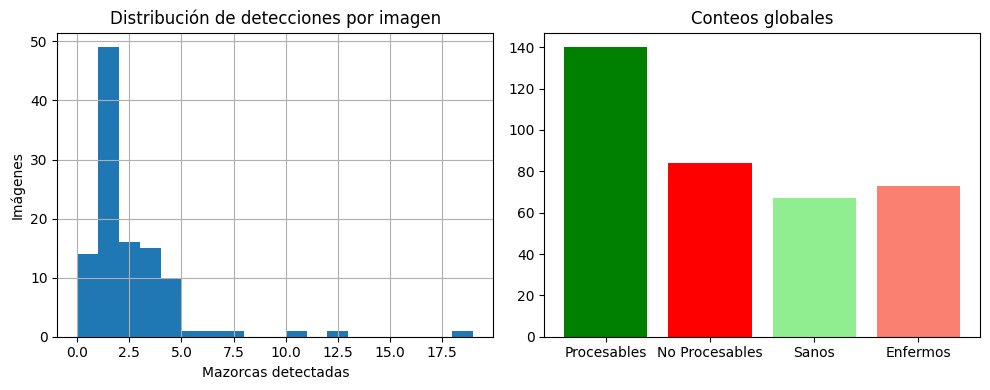


Análisis completado.


In [11]:
# =============================================================================
# Celda 11: Análisis estadístico del CSV
# =============================================================================
df = pd.read_csv(csv_path)

print("=" * 60)
print("ESTADÍSTICAS DEL LOTE")
print("=" * 60)

total_imgs = len(df)
total_mazorcas = df["n_mazorcas_detectadas"].sum()
total_procesables = df["n_procesables"].sum()
total_no_procesables = df["n_no_procesables"].sum()
total_sanos = df["n_sanos"].sum()
total_enfermos = df["n_enfermos"].sum()

print(f"\nImágenes procesadas: {total_imgs}")
print(f"Total mazorcas detectadas: {total_mazorcas}")
print(f"  Procesables: {total_procesables} ({total_procesables/total_mazorcas*100:.1f}%)")
print(f"  No procesables: {total_no_procesables} ({total_no_procesables/total_mazorcas*100:.1f}%)")
print(f"\nDe las procesables:")
print(f"  Sanas: {total_sanos} ({total_sanos/total_procesables*100:.1f}%)")
print(f"  Enfermas: {total_enfermos} ({total_enfermos/total_procesables*100:.1f}%)")

# Imágenes sin detecciones
sin_dets = df[df["n_mazorcas_detectadas"] == 0]
print(f"\nImágenes sin detecciones: {len(sin_dets)}")

# Imágenes con al menos una mazorca enferma
con_enfermos = df[df["n_enfermos"] > 0]
print(f"Imágenes con al menos una mazorca enferma: {len(con_enfermos)}")

# Top motivos de No Procesable
todos_motivos = []
for motivos in df["motivos_no_procesable"]:
    if pd.isna(motivos) or motivos == "":
        continue
    for m in motivos.split("; "):
        todos_motivos.append(m)

if todos_motivos:
    from collections import Counter
    print(f"\n--- Top motivos de rechazo ---")
    for motivo, count in Counter(todos_motivos).most_common(10):
        print(f"  {motivo}: {count} veces")

# Histograma de mazorcas por imagen
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df["n_mazorcas_detectadas"].hist(bins=range(0, df["n_mazorcas_detectadas"].max() + 2))
plt.xlabel("Mazorcas detectadas")
plt.ylabel("Imágenes")
plt.title("Distribución de detecciones por imagen")

plt.subplot(1, 2, 2)
etiquetas = ["Procesables", "No Procesables", "Sanos", "Enfermos"]
valores = [total_procesables, total_no_procesables, total_sanos, total_enfermos]
plt.bar(etiquetas, valores, color=["green", "red", "lightgreen", "salmon"])
plt.title("Conteos globales")
plt.tight_layout()
plt.show()

print("\nAnálisis completado.")